In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import streamlit as stl

In [123]:
emp=pd.read_excel(r'C:\Users\satya\Downloads\Rawdata.xlsx')
emp

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience#$,34 years,Mumbai,5^00#0,2+
1,Teddy^,Testing,45' yr,Bangalore,10%%000,<3
2,Uma#r,Dataanalyst^^#,NaN,NaN,1$5%000,4> yrs
3,Jane,Ana^^lytics,NaN,Hyderbad,2000^0,NaN
4,Uttam*,Statistics,67-yr,NaN,30000-,5+ year
5,Kim,NLP,55yr,Delhi,6000^$0,10+


In [124]:
emp.shape
emp.columns
emp.isnull().sum()
emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      6 non-null      object
 1   Domain    6 non-null      object
 2   Age       4 non-null      object
 3   Location  4 non-null      object
 4   Salary    6 non-null      object
 5   Exp       5 non-null      object
dtypes: object(6)
memory usage: 420.0+ bytes


In [125]:
#Data Cleaning
emp['Name']=emp['Name'].str.replace('\W','',regex=True)
emp['Name']

0     Mike
1    Teddy
2     Umar
3     Jane
4    Uttam
5      Kim
Name: Name, dtype: object

In [126]:
emp['Domain']=emp['Domain'].str.replace('\W','',regex=True)
emp['Domain']

0    Datascience
1        Testing
2    Dataanalyst
3      Analytics
4     Statistics
5            NLP
Name: Domain, dtype: object

In [127]:
emp['Age']=emp['Age'].str.replace('\W','',regex=True)
emp['Age']=emp['Age'].str.extract('(\\d+)')
emp['Age']

0     34
1     45
2    NaN
3    NaN
4     67
5     55
Name: Age, dtype: object

In [128]:
emp['Location']=emp['Location'].str.replace('\W','',regex=True)
emp['Location']

0       Mumbai
1    Bangalore
2          NaN
3     Hyderbad
4          NaN
5        Delhi
Name: Location, dtype: object

In [129]:
emp['Salary']=emp['Salary'].str.replace('\W','',regex=True)
emp['Salary']

0     5000
1    10000
2    15000
3    20000
4    30000
5    60000
Name: Salary, dtype: object

In [130]:
emp['Exp']=emp['Exp'].str.replace('\W','',regex=True)
emp['Exp']=emp['Exp'].str.extract('(\d+)')
emp['Exp']

0      2
1      3
2      4
3    NaN
4      5
5     10
Name: Exp, dtype: object

In [131]:
emp


,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,NaN,NaN,15000,4
3,Jane,Analytics,NaN,Hyderbad,20000,NaN
4,Uttam,Statistics,67,NaN,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [132]:
# filling Missing Value in Data
emp['Age']=emp['Age'].fillna(np.mean(pd.to_numeric(emp['Age'])))
emp['Age']

0       34
1       45
2    50.25
3    50.25
4       67
5       55
Name: Age, dtype: object

In [133]:
emp['Exp']=emp['Exp'].fillna(np.mean(pd.to_numeric(emp['Exp'])))
emp['Exp']

0      2
1      3
2      4
3    4.8
4      5
5     10
Name: Exp, dtype: object

In [134]:
emp['Location']=emp['Location'].fillna(emp['Location'].mode()[0])
emp['Location']

0       Mumbai
1    Bangalore
2    Bangalore
3     Hyderbad
4    Bangalore
5        Delhi
Name: Location, dtype: object

In [135]:
emp.isnull().sum()
clean_data=emp.copy()
clean_data

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50.25,Bangalore,15000,4
3,Jane,Analytics,50.25,Hyderbad,20000,4.8
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


In [136]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      6 non-null      object
 1   Domain    6 non-null      object
 2   Age       6 non-null      object
 3   Location  6 non-null      object
 4   Salary    6 non-null      object
 5   Exp       6 non-null      object
dtypes: object(6)
memory usage: 420.0+ bytes


In [137]:
clean_data['Age']=clean_data['Age'].astype(int)
clean_data['Salary']=clean_data['Salary'].astype(int)
clean_data['Exp']=clean_data['Exp'].astype(int)
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Name      6 non-null      object
 1   Domain    6 non-null      object
 2   Age       6 non-null      int64 
 3   Location  6 non-null      object
 4   Salary    6 non-null      int64 
 5   Exp       6 non-null      int64 
dtypes: int64(3), object(3)
memory usage: 420.0+ bytes


In [138]:
clean_data['Name']=clean_data['Name'].astype('category')
clean_data['Location']=clean_data['Location'].astype('category')
clean_data['Domain']=clean_data['Domain'].astype('category')
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Name      6 non-null      category
 1   Domain    6 non-null      category
 2   Age       6 non-null      int64   
 3   Location  6 non-null      category
 4   Salary    6 non-null      int64   
 5   Exp       6 non-null      int64   
dtypes: category(3), int64(3)
memory usage: 938.0 bytes


In [139]:
clean_data.to_csv('Clean_data.csv')

In [140]:
# for find Data file location where file stored
import os
os.getcwd()

'c:\\Users\\satya\\AVS Code\\Sns_Matplot_charts'

Lets Apply EDA Techniques

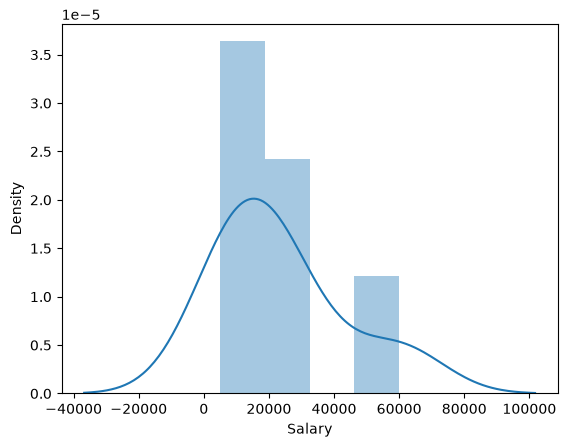

In [141]:
clean_data['Salary']
visual1=sns.distplot(clean_data['Salary'])

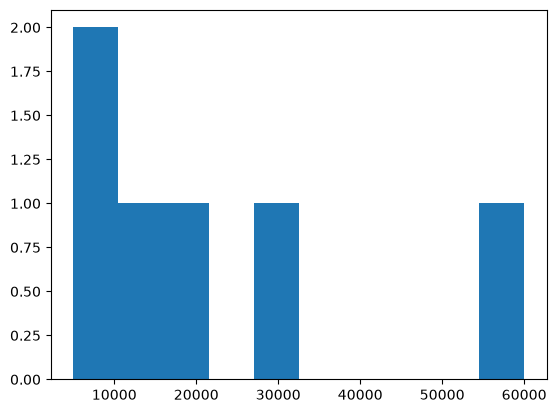

In [142]:
visual2=plt.hist(clean_data['Salary'])

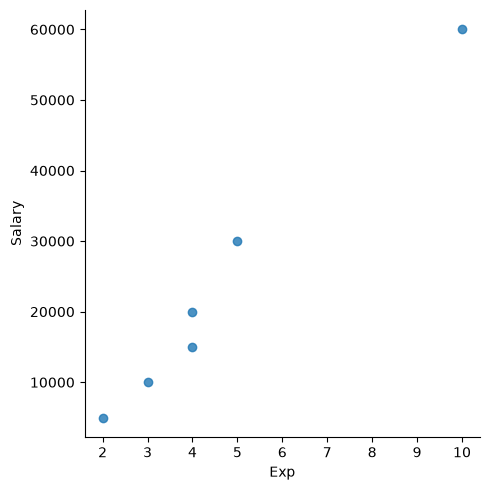

In [143]:
#visual3=sns.lmplot(data=clean_data,x='Exp',y='Salary')
visual3=sns.lmplot(data=clean_data,x='Exp',y='Salary',fit_reg=False)

In [144]:
#Create Depanded or Independed variable
iv_variable=clean_data[['Name','Domain','Location','Age','Exp']]
iv_variable
#clean_data.head(1)

,Name,Domain,Location,Age,Exp
0,Mike,Datascience,Mumbai,34,2
1,Teddy,Testing,Bangalore,45,3
2,Umar,Dataanalyst,Bangalore,50,4
3,Jane,Analytics,Hyderbad,50,4
4,Uttam,Statistics,Bangalore,67,5
5,Kim,NLP,Delhi,55,10


In [145]:
dv_variable=clean_data['Salary']
dv_variable

0     5000
1    10000
2    15000
3    20000
4    30000
5    60000
Name: Salary, dtype: int64

In [146]:
imputation=pd.get_dummies(clean_data,dtype=int)

In [147]:
imputation

,Age,Salary,Exp,Name_Jane,Name_Kim,Name_Mike,Name_Teddy,Name_Umar,Name_Uttam,Domain_Analytics,Domain_Dataanalyst,Domain_Datascience,Domain_NLP,Domain_Statistics,Domain_Testing,Location_Bangalore,Location_Delhi,Location_Hyderbad,Location_Mumbai
0,34,5000,2,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
1,45,10000,3,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0
2,50,15000,4,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0
3,50,20000,4,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
4,67,30000,5,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0
5,55,60000,10,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0


In [152]:
emp

,Name,Domain,Age,Location,Salary,Exp
0,Mike,Datascience,34,Mumbai,5000,2
1,Teddy,Testing,45,Bangalore,10000,3
2,Umar,Dataanalyst,50.25,Bangalore,15000,4
3,Jane,Analytics,50.25,Hyderbad,20000,4.8
4,Uttam,Statistics,67,Bangalore,30000,5
5,Kim,NLP,55,Delhi,60000,10


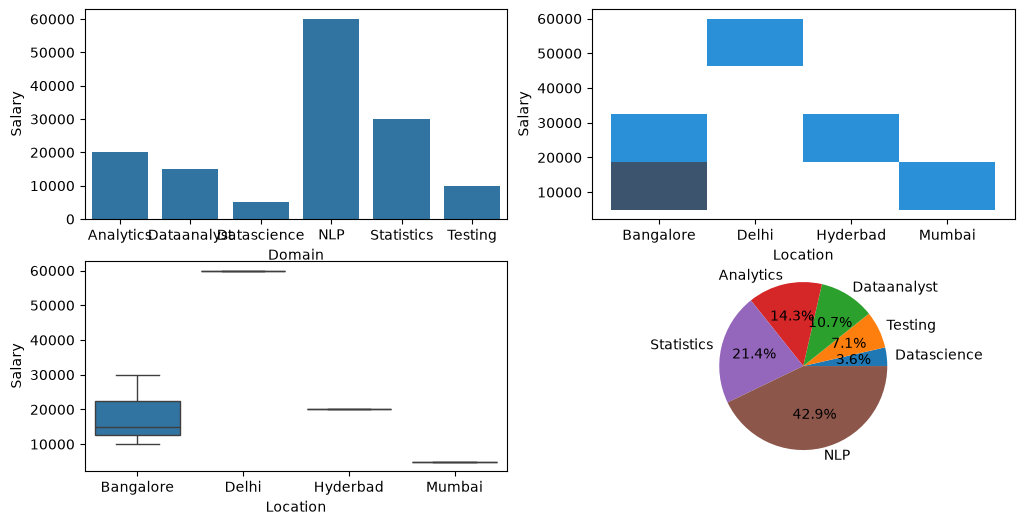

In [156]:
fig, axes=plt.subplots(nrows=2,ncols=2,figsize=(12,6))
sns.barplot(data=clean_data,x='Domain',y='Salary',ax=axes[0,0])
sns.histplot(data=clean_data,x='Location',y='Salary',ax=axes[0,1])
sns.boxplot(data=clean_data,x='Location',y='Salary',ax=axes[1,0])
plt.pie(data=clean_data,x='Salary',labels='Domain',autopct='%1.1f%%')